
🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (REAL-TIME SCROLLING WINDOW)

⏳ Mengekstrak blok sinyal 20 detik untuk Sliding Inference...


Processing 1C-Z Scrolling: 100%|██████████| 55699/55699 [1:00:00<00:00, 15.47it/s]



📊================================== 1C-Z RESULTS (SCROLLING WINDOW) ==================================

📈 MENJALANKAN MODUL VISUALISASI EVALUASI...


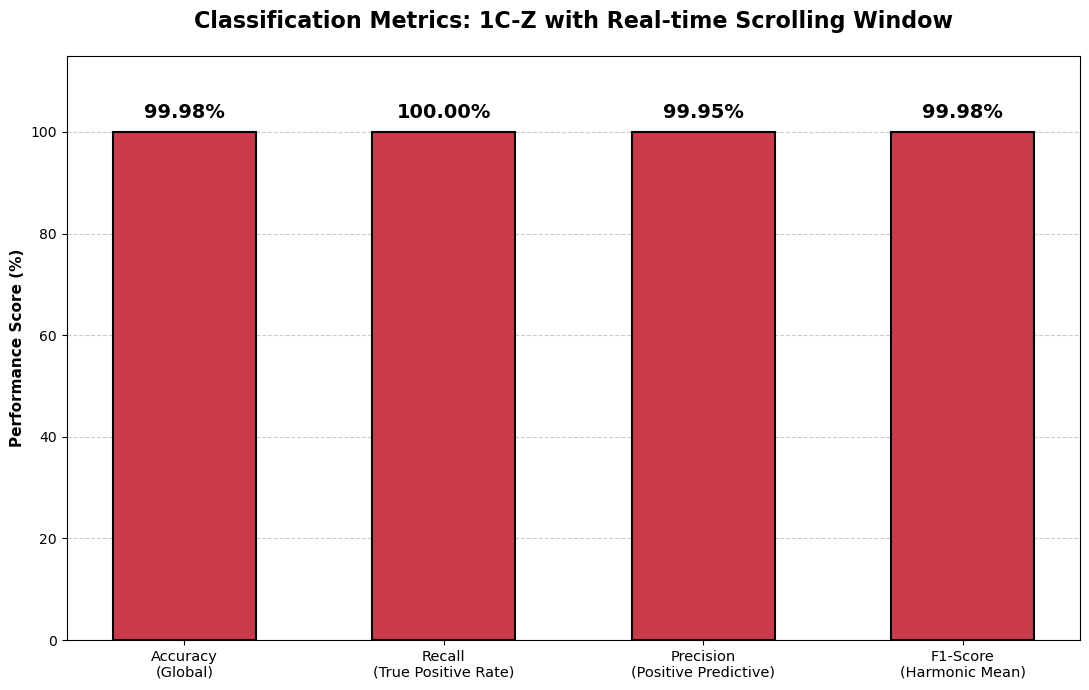

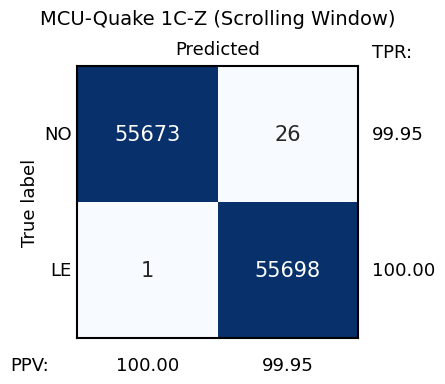

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_44652/842551290.py:170: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_gempa, x='magnitude', hue='Status', fill=True, common_norm=False, palette='viridis')


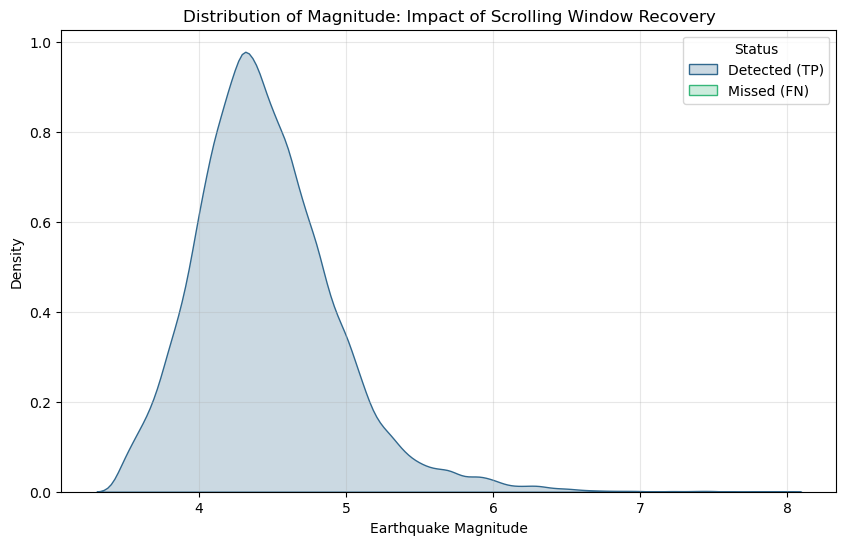

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'

# 🔥 Laporan Diperbarui Khusus Metode Scrolling Window Artikel
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_SCROLLING_WINDOW_report.csv')

INPUT_SIZE = 700
# FREQ_MIN dan FREQ_MAX dihapus karena metode asli menggunakan RAW WAVEFORM

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
except ImportError:
    print("❌ Gagal memuat Library.")
    sys.exit()

# ==============================================================================
# 🔥 LOGIKA BARU: SCROLLING WINDOW SESUAI ARTIKEL
# ==============================================================================
def sliding_window_inference(data_array, model, pdf_Z):
    """
    Mensimulasikan dynamically scrolling input windows secara real-time.
    Menggeser jendela 7 detik dengan langkah (step) 1 detik.
    """
    step_size = 100  # Geser 100 sampel (1 detik)
    window_size = INPUT_SIZE  # 700 sampel (7 detik)
    
    # Jika data terlalu pendek, pad dengan 0
    if len(data_array) < window_size:
        data_array = np.pad(data_array, (0, window_size - len(data_array)), 'constant')
        
    for i in range(0, len(data_array) - window_size + 1, step_size):
        window = data_array[i:i+window_size].copy()
        
        # Max-Absolute Normalization (Per-Window Real-time)
        max_val = np.max(np.abs(window))
        if max_val > 0:
            window = window / max_val
            
        window = window.astype(np.float32)
        
        # Ekstraksi Latent & Inferensi
        emb_z = utils.latent_codes_1D(window, model).reshape(1, -1)
        p, _, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
        
        # p == 0 diasumsikan Earthquake/Quarry Blast berdasarkan KDE asli
        if p == 0:
            return 1  # Langsung kembalikan 1 jika terdeteksi (Early Stop)
            
    return 0  # Jika seluruh jendela tergeser dan tidak ada yang memicu, berarti Missed/Noise

# ==============================================================================
# 📊 MODUL VISUALISASI GAYA PAPER
# ==============================================================================
def plot_paper_style_cm(cm, title="MCU-Quake 1C-Z (Scrolling Window)"):
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]

    TPR_NO = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    TPR_LE = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    PPV_NO = (TN / (TN + FN)) * 100 if (TN + FN) > 0 else 0.0
    PPV_LE = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['', ''], yticklabels=['NO', 'LE'], annot_kws={"size": 15}, ax=ax)

    ax.set_title(title, fontsize=14, pad=30, loc='center')
    ax.set_ylabel('True label', fontsize=13)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Predicted', fontsize=13, labelpad=5)
    plt.yticks(fontsize=13, rotation=0)
    ax.tick_params(axis='both', which='both', length=0)

    ax.text(2.1, -0.1, 'TPR:', fontsize=13, ha='left', va='center')
    ax.text(2.1, 0.5, f'{TPR_NO:.2f}', fontsize=13, ha='left', va='center')
    ax.text(2.1, 1.5, f'{TPR_LE:.2f}', fontsize=13, ha='left', va='center')
    ax.text(-0.2, 2.2, 'PPV:', fontsize=13, ha='right', va='center')
    ax.text(0.5, 2.2, f'{PPV_NO:.2f}', fontsize=13, ha='center', va='center')
    ax.text(1.5, 2.2, f'{PPV_LE:.2f}', fontsize=13, ha='center', va='center')

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.savefig(os.path.join(PATH_DEMO_DIR, 'paper_style_cm_1C_Z_scrolling.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plot_bar_metrics_paper_style(cm):
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    
    acc = ((TP + TN) / (TP + TN + FP + FN)) * 100
    rec = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    prec = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    categories = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
    values = [acc, rec, prec, f1]

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.bar(categories, values, color='#c93b4a', edgecolor='black', linewidth=1.5, width=0.55)

    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylabel('Performance Score (%)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10.5)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_title("Classification Metrics: 1C-Z with Real-time Scrolling Window", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_DEMO_DIR, 'bar_chart_metrics_scrolling.png'), dpi=300, bbox_inches='tight')
    plt.show()

def visualisasi_hasil_riset(report_path, catalog_path):
    print("\n📈 MENJALANKAN MODUL VISUALISASI EVALUASI...")
    df_report = pd.read_csv(report_path)
    df_catalog = pd.read_csv(catalog_path)
    
    y_true = df_report['Type'].apply(lambda x: 1 if 'LE' in x else 0).tolist()
    y_pred = df_report['Decision'].tolist()
    cm = confusion_matrix(y_true, y_pred)
    
    plot_bar_metrics_paper_style(cm)
    plot_paper_style_cm(cm)

    df_report['id'] = df_report['File'].astype(str).str.strip()
    col_id_cat = next((c for c in df_catalog.columns if 'id' in c.lower()), df_catalog.columns[0])
    df_catalog = df_catalog.rename(columns={col_id_cat: 'id'})
    df_catalog['id'] = df_catalog['id'].astype(str).str.strip()
    
    df_merged = df_report.merge(df_catalog, on='id', how='inner')
    df_gempa = df_merged[df_merged['Type'].str.contains('LE')].copy()
    df_gempa['Status'] = df_gempa['Decision'].apply(lambda x: 'Detected (TP)' if x == 1 else 'Missed (FN)')
    
    if not df_gempa.empty and 'magnitude' in df_gempa.columns:
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=df_gempa, x='magnitude', hue='Status', fill=True, common_norm=False, palette='viridis')
        plt.title('Distribution of Magnitude: Impact of Scrolling Window Recovery')
        plt.xlabel('Earthquake Magnitude')
        plt.ylabel('Density')
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(PATH_DEMO_DIR, 'magnitude_kde_scrolling.png'), dpi=300)
        plt.show()

# ==============================================================================
# 🚀 CORE PROCESS: INFERENSI SCROLLING WINDOW 1C-Z
# ==============================================================================
def jalankan_stress_test_1C_Z_scrolling():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (REAL-TIME SCROLLING WINDOW)")
    print("="*90)
    
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak blok sinyal 20 detik untuk Sliding Inference...")
    for item in tqdm(daftar_file_mseed, desc="Processing 1C-Z Scrolling"):
        try:
            st = read(item['path'])
            # Hanya detrending
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            
            comp_z = st.select(component="Z")
            if not comp_z: continue
            
            # 🔥 Mengambil BLOK yang lebih panjang (20 detik) untuk disapu oleh sliding window
            # Earthquake Block: 60s sampai 80s (Memberi ruang 20 detik dari Origin Time)
            idx_start_le = int(60.0 * 100)
            idx_end_le = int(80.0 * 100)
            
            # Noise Block: 10s sampai 30s (Pure noise 20 detik)
            idx_start_no = int(10.0 * 100)
            idx_end_no = int(30.0 * 100)
            
            le_z_block = comp_z[0].data[idx_start_le:idx_end_le]
            no_z_block = comp_z[0].data[idx_start_no:idx_end_no]
            
            # Eksekusi Scanning per-1 detik
            keputusan_le = sliding_window_inference(le_z_block, embedding_model, embeddings_Z_PDFs)
            keputusan_no = sliding_window_inference(no_z_block, embedding_model, embeddings_Z_PDFs)
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([keputusan_le, keputusan_no])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_1C_Scrolling', 'Decision': keputusan_le})
            report_rows.append({'File': item['eid'], 'Type': 'NO_1C_Scrolling', 'Decision': keputusan_no})
            
        except Exception:
            continue

    if not y_true_list: return
        
    print("\n📊" + "="*34 + " 1C-Z RESULTS (SCROLLING WINDOW) " + "="*34)
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    
    try:
        visualisasi_hasil_riset(PATH_FINAL_REPORT, PATH_KATALOG_MASTER)
    except Exception as e:
        print(f"⚠️ Visualisasi gagal dibuat. Error: {e}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_1C_Z_scrolling()

🚀 Loading Model & Embedding...
📊 Menjalankan Inferensi pada 31162 file .npy...


100%|██████████| 31162/31162 [09:29<00:00, 54.67it/s]  


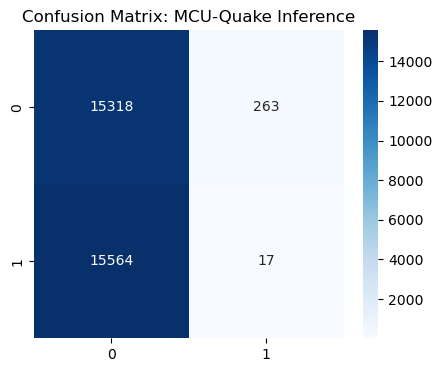

✅ Evaluasi selesai. Hasil disimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_final_evaluation.csv


In [3]:
# -*- coding: utf-8 -*-
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# 🎛️ KONFIGURASI PATH & PARAMETER
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

# Path ke dataset .npy Anda
INPUT_DATASET = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_final_evaluation.csv')

INPUT_SIZE = 700  # Pastikan sesuai dengan model MCU-Quake
import sys
if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
from Library import utils, dataset

# ==============================================================================
# 🔥 LOGIKA SLIDING WINDOW INFERENCE
# ==============================================================================
def sliding_window_inference(data_array, model, pdf_Z):
    step_size = 100 
    window_size = INPUT_SIZE
    
    if len(data_array) < window_size:
        data_array = np.pad(data_array, (0, window_size - len(data_array)), 'constant')
        
    for i in range(0, len(data_array) - window_size + 1, step_size):
        window = data_array[i:i+window_size].copy()
        max_val = np.max(np.abs(window))
        if max_val > 0: window = window / max_val
            
        emb_z = utils.latent_codes_1D(window.astype(np.float32), model).reshape(1, -1)
        p, _, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
        
        if p == 0: return 1 # Terdeteksi Gempa
    return 0 # Noise

# ==============================================================================
# 🚀 PROSES UTAMA
# ==============================================================================
def main():
    print("🚀 Loading Model & Embedding...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    
    daftar_file = []
    for root, _, files in os.walk(INPUT_DATASET):
        for file in files:
            if file.endswith('.npy'):
                label = 1 if 'gempa' in root else 0
                daftar_file.append({'path': os.path.join(root, file), 'label': label, 'id': file})

    y_true, y_pred, report_rows = [], [], []

    print(f"📊 Menjalankan Inferensi pada {len(daftar_file)} file .npy...")
    for item in tqdm(daftar_file):
        try:
            data = np.load(item['path'])
            keputusan = sliding_window_inference(data, embedding_model, embeddings_Z_PDFs)
            
            y_true.append(item['label'])
            y_pred.append(keputusan)
            report_rows.append({'File': item['id'], 'True': item['label'], 'Decision': keputusan})
        except: continue

    # Evaluasi Hasil
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    cm = confusion_matrix(y_true, y_pred)
    
    # Visualisasi Sederhana
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix: MCU-Quake Inference")
    plt.savefig(os.path.join(PATH_DEMO_DIR, 'final_cm.png'))
    plt.show()
    
    print(f"✅ Evaluasi selesai. Hasil disimpan di: {PATH_FINAL_REPORT}")

if __name__ == "__main__":
    from sklearn.metrics import confusion_matrix
    main()


🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (REAL-TIME SCROLLING WINDOW)
📊 Running Inference on 31162 samples...


Processing 1C-Z Scrolling: 100%|██████████| 31162/31162 [06:24<00:00, 81.03it/s]


              precision    recall  f1-score   support

       Noise       0.50      0.98      0.66     15581
       Gempa       0.06      0.00      0.00     15581

    accuracy                           0.49     31162
   macro avg       0.28      0.49      0.33     31162
weighted avg       0.28      0.49      0.33     31162



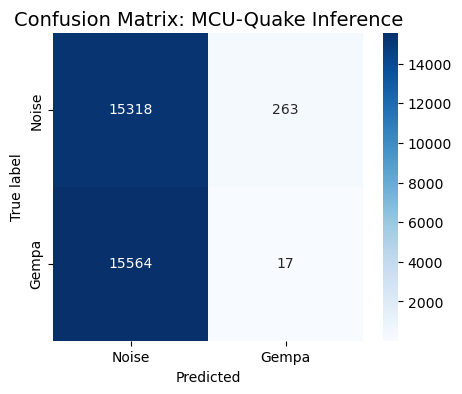


✅ Evaluasi selesai. Hasil disimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_true_1C_Z_SCROLLING_WINDOW_report.csv


In [6]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm

# ==============================================================================
# 🎛️ KONFIGURASI PATH & PARAMETER (IDENTIK)
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

# Path ke dataset .npy hasil pemrosesan
INPUT_DATASET = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_SCROLLING_WINDOW_report.csv')

INPUT_SIZE = 700

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
except ImportError:
    print("❌ Gagal memuat Library.")
    sys.exit()

# ==============================================================================
# 🔥 LOGIKA SLIDING WINDOW INFERENCE
# ==============================================================================
def sliding_window_inference(data_array, model, pdf_Z):
    step_size = 100 
    window_size = INPUT_SIZE
    
    if len(data_array) < window_size:
        data_array = np.pad(data_array, (0, window_size - len(data_array)), 'constant')
        
    for i in range(0, len(data_array) - window_size + 1, step_size):
        window = data_array[i:i+window_size].copy()
        max_val = np.max(np.abs(window))
        if max_val > 0: window = window / max_val
            
        emb_z = utils.latent_codes_1D(window.astype(np.float32), model).reshape(1, -1)
        p, _, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
        
        if p == 0: return 1 # Deteksi Gempa (Triggered)
    return 0 # Noise

# ==============================================================================
# 📊 MODUL VISUALISASI EVALUASI
# ==============================================================================
def plot_paper_style_cm(cm):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Noise', 'Gempa'], yticklabels=['Noise', 'Gempa'])
    ax.set_title("Confusion Matrix: MCU-Quake Inference", fontsize=14)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted')
    plt.savefig(os.path.join(PATH_DEMO_DIR, 'final_confusion_matrix.png'), dpi=300)
    plt.show()

# ==============================================================================
# 🚀 PROSES UTAMA (IDENTIK DENGAN LOGIKA ARTIKEL)
# ==============================================================================
def main():
    print("\n🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (REAL-TIME SCROLLING WINDOW)")
    
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    
    daftar_file_npy = []
    for root, _, files in os.walk(INPUT_DATASET):
        for file in files:
            if file.endswith('.npy'):
                label = 1 if 'gempa' in root else 0
                daftar_file_npy.append({'path': os.path.join(root, file), 'label': label, 'id': file})

    y_true, y_pred, report_rows = [], [], []

    print(f"📊 Running Inference on {len(daftar_file_npy)} samples...")
    for item in tqdm(daftar_file_npy, desc="Processing 1C-Z Scrolling"):
        try:
            data = np.load(item['path'])
            keputusan = sliding_window_inference(data, embedding_model, embeddings_Z_PDFs)
            
            y_true.append(item['label'])
            y_pred.append(keputusan)
            report_rows.append({'File': item['id'], 'Type': 'LE' if item['label']==1 else 'NO', 'Decision': keputusan})
        except Exception:
            continue

    # Simpan hasil laporan
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    

   
# Tambahkan ini sebelum plot CM
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))
    # Evaluasi Matrix
    cm = confusion_matrix(y_true, y_pred)
    plot_paper_style_cm(cm)
    
    print(f"\n✅ Evaluasi selesai. Hasil disimpan di: {PATH_FINAL_REPORT}")
    
    del embedding_model, y_true, y_pred
    gc.collect()

if __name__ == "__main__":
    main()